In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import defaultdict
from codes.triplets import TripletsEngine
import os
import torch
import pandas as pd
import json
import random

PATH = "/home/cc/phd/KGEmbeddings/"
EMBEDDING_DIM = 400
DATA = "umls"
MODEL_NAME = "RotatE"
# MODEL_PATH = "/home/cc/phd/KGEmbeddings/models/TransE_FB15k_0/"
# MODEL_PATH = "/home/cc/phd/KGEmbeddings/models/RotatE_FB15k_0/"
MODEL_PATH = f"{PATH}models/{MODEL_NAME}_{DATA}_0"
# DICTS_DIR = "/home/cc/phd/KGEmbeddings/data/FB15k/"
DICTS_DIR = f"{PATH}data/{DATA}"

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"

kg = TripletsEngine(os.path.join(DICTS_DIR), ext="txt" if DATA.startswith("FB15k") else "csv", from_splits=True)

entity_embeddings = torch.from_numpy(np.load(os.path.join(MODEL_PATH, 'entity_embedding.npy'))).to(device)
relation_embeddings = torch.from_numpy(np.load(os.path.join(MODEL_PATH, 'relation_embedding.npy'))).to(device)

e_map = pd.read_json("/home/cc/phd/KGEmbeddings/data/umls/entity_map.json", typ='series').to_dict()
r_map = pd.read_json("/home/cc/phd/KGEmbeddings/data/umls/rel_map.json", typ='series').to_dict()

# UMLS maps
inv_e_map = {v: k for k, v in e_map.items()}
inv_r_map = {v: k for k, v in r_map.items()}

# concepts = pd.read_csv("/home/cc/phd/KGGraphRAG/umls/MRCONSO.RRF", sep="|", header=None,  usecols=[0, 1, 14], names=["CUI", "LNG", "NAME"], low_memory=False)
# concepts = concepts[concepts['LNG'] == 'ENG']
# cui_to_name = dict(zip(concepts['CUI'], concepts['NAME']))

with open("/home/cc/phd/KGEmbeddings/data/umls/cui_to_name.json", "r") as f:
    cui_to_name = json.load(f)

TARGET_RELS = ["may_treat", "contraindicated_with_disease", "manifestation_of", "causative_agent_of", "pathological_process_of",
            "has_finding_site", "associated_morphology_of", "clinically_associated_with", "therapeutic_class_of", "has_phenotype",
            "associated_with", "co-occurs_with", "has_focus", "has_component", "has_active_ingredient", "has_ingredient", "used_for",
            "physiologic_effect_of", "mechanism_of_action_of", "has_procedure_site", "has_direct_procedure_site", "location_of", "method_of"]

target_rels_ids = [r_map[rel] for rel in TARGET_RELS if rel in r_map]

tests = kg.triplets[np.isin(kg.triplets[:,1], target_rels_ids)]
# tests = kg.triplets[kg.train_set]

def get_name(dic, cui):
    return dic.get(cui, 'N/A')

Loading precomputed mappings...


In [ ]:
df = pd.read_csv("/home/cc/phd/KGEmbeddings/data/umls/train_filt.csv")

unique_nodes = pd.Index(df["head_id"].tolist() + df["tail_id"].tolist()).unique()

# Create mapping from old to new
node_mapping = {old: new for new, old in enumerate(sorted(unique_nodes))}

# Apply mapping
df["head_id"] = df["head_id"].map(node_mapping)
df["tail_id"] = df["tail_id"].map(node_mapping)

# --- Remap relation IDs ---
unique_relations = df["relation_id"].unique()
relation_mapping = {old: new for new, old in enumerate(sorted(unique_relations))}

df["relation_id"] = df["relation_id"].map(relation_mapping)

new_node_names = {new_id: inv_e_map[old_id] for old_id, new_id in node_mapping.items() if old_id in inv_e_map}
new_relation_names = {new_id: inv_r_map[old_id] for old_id, new_id in relation_mapping.items() if old_id in inv_r_map}

inv_e_map = new_node_names
inv_r_map = new_relation_names

In [ ]:
# Collect all vectors we’ll need
vectors = []
labels = []

idx = np.random.randint(0, len(tests), size=2)

for h, r, t in tests[idx]:
    h_vec = entity_embeddings[h]
    r_vec = relation_embeddings[r]
    t_vec = entity_embeddings[t]
    h_plus_r = h_vec + r_vec
    
    vectors.extend([h_vec, t_vec, h_plus_r])
    labels.extend([f"{get_name(cui_to_name, inv_e_map[h])} (head)", f"{get_name(cui_to_name, inv_e_map[t])} (tail)", f"{get_name(cui_to_name, inv_e_map[h])}+{inv_r_map[r]}"])

# Project to 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.vstack(vectors))

# Plot
plt.figure(figsize=(14, 12))
for i in range(0, len(proj), 3):
    h, t, hr = proj[i], proj[i+1], proj[i+2]
    
    # Points
    plt.scatter(*h, color="blue")
    plt.scatter(*t, color="green")
    plt.scatter(*hr, color="orange")

    # Labels
    plt.text(h[0], h[1], labels[i], fontsize=9)
    plt.text(t[0], t[1], labels[i+1], fontsize=9)
    plt.text(hr[0], hr[1], labels[i+2], fontsize=9)
    
    # Arrows: h → h+r and h+r → t
    plt.arrow(h[0], h[1], hr[0]-h[0], hr[1]-h[1],
              color="red", head_width=0.03, length_includes_head=True)
    plt.arrow(hr[0], hr[1], t[0]-hr[0], t[1]-hr[1],
              color="gray", linestyle="--", alpha=0.5)

plt.title("TransE Translation Visualization (h + r ≈ t)")
plt.xlabel("PCA dim 1")
plt.ylabel("PCA dim 2")
plt.grid(True)
plt.show()

[(np.int64(832485), np.int64(63), np.int64(844064)), (np.int64(832485), np.int64(62), np.int64(258)), (np.int64(832485), np.int64(63), np.int64(832482))]


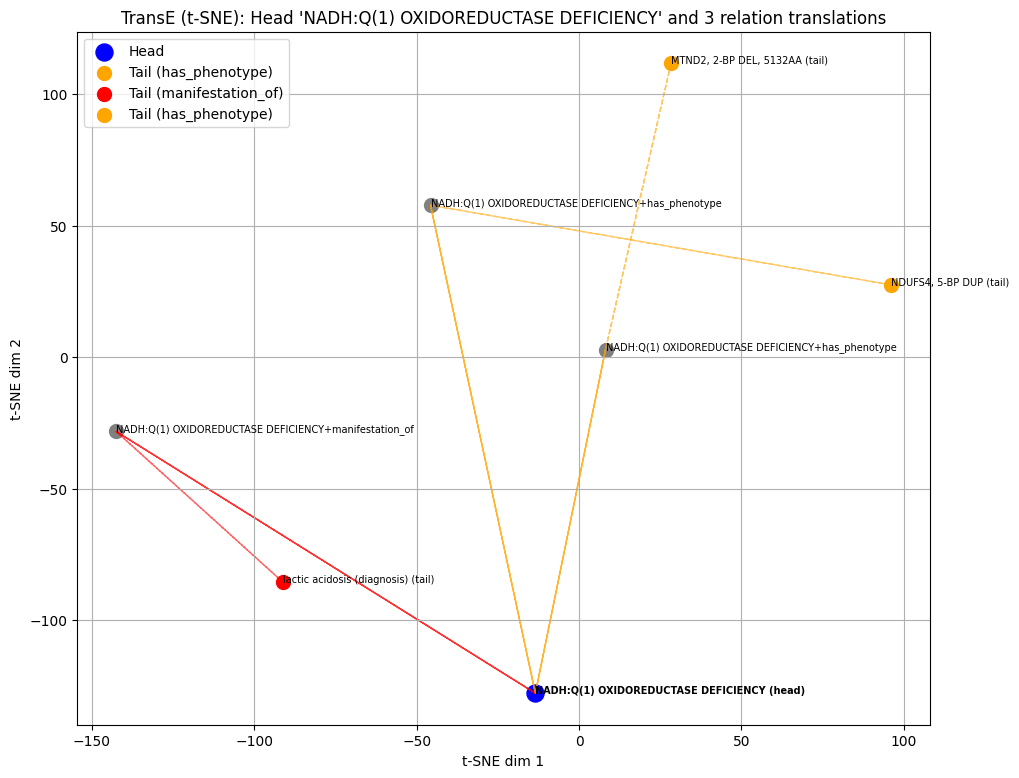

In [ ]:
def rotate_projection(head_emb, rel_emb, embedding_range=torch.tensor([[0.1300]]), pi=np.pi):
    re_head, im_head = torch.chunk(head_emb, 2, dim=-1)

    embedding_range = torch.tensor([[0.1300]])

    # map relation to phase in [-pi, pi]
    phase_relation = rel_emb / (embedding_range.item() / pi)
    re_relation = torch.cos(phase_relation)
    im_relation = torch.sin(phase_relation)

    re_target = re_head * re_relation - im_head * im_relation
    im_target = re_head * im_relation + im_head * re_relation

    # recombine real & imag into a single vector
    return torch.cat([re_target, im_target], dim=-1)

proj_algo = "tsne"  # "pca" or "tsne"

head_counts = defaultdict(list)
for (h, r, t) in tests:
    head_counts[h].append((h, r, t))

valid_heads = [h for h, triples in head_counts.items() if len(triples) >= 3]
if not valid_heads:
    raise ValueError("No head entity appears in at least 3 triples.")

# Choose one head randomly
head = random.choice(valid_heads)
triples_for_head = head_counts[head]

n_t = 2
# Pick 3 triples from this head
if len(triples_for_head) > n_t:
    triples_for_head = random.sample(triples_for_head, n_t)

vectors = []
labels = []
colors = []

h_vec = entity_embeddings[head]
vectors.append(h_vec)
labels.append(f"{get_name(cui_to_name, inv_e_map[head])} (head)")
# labels.append(f"{head} (head)")

print(triples_for_head)

for (h, r, t) in triples_for_head:
    r_vec = relation_embeddings[r]
    t_vec = entity_embeddings[t]
    # h_plus_r = h_vec + r_vec
    h_plus_r = rotate_projection(h_vec, r_vec)

    vectors.extend([t_vec, h_plus_r])
    # labels.extend([
    #     f"{t} (tail)",
    #     f"{h}+{r}"
    # ])
    labels.extend([
        f"{get_name(cui_to_name, inv_e_map[t])} (tail)",
        f"{get_name(cui_to_name, inv_e_map[head])}+{inv_r_map[r]}"
    ])
    colors.append(r)

if proj_algo == "tsne":
    tsne = TSNE(n_components=2, random_state=42, perplexity=5, init="pca")
    proj = tsne.fit_transform(np.vstack(vectors))
else:
    pca = PCA(n_components=2)
    proj = pca.fit_transform(np.vstack(vectors))

# The first point corresponds to the head
head_2d = proj[0]

# --- 4️⃣ Plot ---
plt.figure(figsize=(11, 9))
unique_relations = list(set(colors))
rel_to_color = {r: c for r, c in zip(unique_relations, ["red", "orange", "purple", "teal", "brown"])}

plt.scatter(*head_2d, color="blue", s=150, label="Head")
plt.text(head_2d[0], head_2d[1], labels[0], fontsize=7, fontweight="bold")

# Each triple now has two points: tail and h+r
for i, (h, r, t) in enumerate(triples_for_head):
    color = rel_to_color[r]
    t_idx = 1 + 2 * i
    hr_idx = t_idx + 1
    t2d, hr2d = proj[t_idx], proj[hr_idx]

    # Points
    plt.scatter(*t2d, color=color, s=100, label=f"Tail ({inv_r_map[r]})")
    # plt.scatter(*t2d, color=color, s=100, label=f"Tail ({r})")
    plt.scatter(*hr2d, color="gray", s=100)

    # Labels
    plt.text(t2d[0], t2d[1], labels[t_idx], fontsize=7)
    plt.text(hr2d[0], hr2d[1], labels[hr_idx], fontsize=7)

    # Arrows: h → h+r and h+r → t
    plt.arrow(head_2d[0], head_2d[1], hr2d[0]-head_2d[0], hr2d[1]-head_2d[1],
              color=color, head_width=0.05, length_includes_head=True, alpha=0.8)
    plt.arrow(hr2d[0], hr2d[1], t2d[0]-hr2d[0], t2d[1]-hr2d[1],
              color=color, linestyle="--", alpha=0.6)

plt.title(f"TransE (t-SNE): Head '{get_name(cui_to_name, inv_e_map[head])}' and 3 relation translations")
# plt.title(f"TransE (t-SNE): Head '{head}' and 3 relation translations")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.grid(True)
plt.show()